# Stochastic Interest Rate Modelling and Prediction
## Implementing, Calibrating, and Extending the Cox-Ingersoll-Ross Model

**Objective:** build a clean, reproducible notebook that preprocesses noisy yield-curve data, calibrates a base CIR short-rate model, reconstructs the yield curve from the 3M rate, and then improves the model using a CIR++-style walk-forward residual extension.

This notebook is written as a combined **code notebook + report**, as required in the problem statement.

## 1. Problem interpretation

The dataset contains daily zero-coupon yields for nine maturities:

- 3M, 6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y, 30Y.

The challenge is not just forecasting a scalar time series. The actual task is harder: for each test date, use the **3M yield as the short-rate proxy** and reconstruct the rest of the curve from 6M to 30Y.

The base model is the one-factor Cox-Ingersoll-Ross model:

\[
dr_t = \kappa(\theta-r_t)dt + \sigma\sqrt{r_t}\,dW_t
\]

where:

- \(\kappa\) = mean-reversion speed,
- \(\theta\) = long-run mean rate,
- \(\sigma\) = volatility coefficient,
- \(r_t\) = short rate proxied by the 3M yield.


In [ ]:
# If running in a fresh Colab runtime, uncomment the next line only if a package is missing.
# !pip install numpy pandas matplotlib scipy scikit-learn

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Colab/local compatible paths.
# In Colab, upload the CSV files into the same directory as this notebook or into /content.
DATA_DIR = Path(".")
if not (DATA_DIR / "train_data.csv").exists() and Path("/content/train_data.csv").exists():
    DATA_DIR = Path("/content")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

TRAIN_PATH = DATA_DIR / "train_data.csv"
TEST_PATH = DATA_DIR / "test_data.csv"
TEST_3M_PATH = DATA_DIR / "test_data_3M.csv"

print("Using data directory:", DATA_DIR.resolve())

Using data directory: /mnt/data/Finance_CIR_Project


## 2. Data engineering and preprocessing

The cleaning pipeline below does four things:

1. strips column-name whitespace,
2. parses dates and sorts observations chronologically,
3. converts all yield columns to numeric values,
4. interpolates missing values and replaces extreme local outliers using a Hampel-style rolling median filter.

The point of preprocessing is not to force the data to look nice; it is to prevent calibration from being dominated by formatting errors, missing values, or single-day spikes.

In [ ]:
TENOR_MAP = {
    "ZC025YR": 0.25,
    "ZC050YR": 0.50,
    "ZC075YR": 0.75,
    "ZC100YR": 1.00,
    "ZC200YR": 2.00,
    "ZC500YR": 5.00,
    "ZC1000YR": 10.00,
    "ZC2000YR": 20.00,
    "ZC3000YR": 30.00,
}

SHORT_COL = "ZC025YR"
TARGET_COLS = ["ZC050YR", "ZC075YR", "ZC100YR", "ZC200YR", "ZC500YR", "ZC1000YR", "ZC2000YR", "ZC3000YR"]
TARGET_TENORS = np.array([TENOR_MAP[c] for c in TARGET_COLS], dtype=float)


def clean_yield_dataframe(path: Path, name: str, use_hampel: bool = True):
    """Load and clean a yield-curve CSV file.

    Parameters
    ----------
    path:
        CSV file path.
    name:
        Human-readable dataset name used in the cleaning report.
    use_hampel:
        Whether to apply rolling median outlier detection to yield columns.

    Returns
    -------
    clean_df, report
        Clean dataframe and a dictionary summarising cleaning actions.
    """
    df = pd.read_csv(path)
    original_shape = df.shape

    # CSV headers in the supplied files contain leading spaces. Strip them immediately.
    df.columns = df.columns.str.strip()

    if "Date" not in df.columns:
        raise ValueError(f"{name}: Date column not found. Columns are: {list(df.columns)}")

    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).sort_values("Date").drop_duplicates("Date", keep="last")

    yield_cols = [c for c in df.columns if c != "Date"]
    for c in yield_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    missing_before = int(df[yield_cols].isna().sum().sum())
    df = df.set_index("Date")
    df[yield_cols] = df[yield_cols].replace([np.inf, -np.inf], np.nan)
    df[yield_cols] = df[yield_cols].interpolate(method="time", limit_direction="both").ffill().bfill()

    outlier_counts = {}
    if use_hampel:
        for c in yield_cols:
            s = df[c].copy()
            rolling_median = s.rolling(window=31, center=True, min_periods=5).median()
            rolling_mad = (s - rolling_median).abs().rolling(window=31, center=True, min_periods=5).median()
            threshold = 8.0 * 1.4826 * rolling_mad
            mask = (s - rolling_median).abs() > threshold
            mask = mask.fillna(False)
            outlier_counts[c] = int(mask.sum())
            if mask.any():
                df.loc[mask, c] = np.nan
                df[c] = df[c].interpolate(method="time", limit_direction="both").ffill().bfill()

    # Yields must be non-negative for the square-root CIR diffusion.
    df[yield_cols] = df[yield_cols].clip(lower=1e-8)
    missing_after = int(df[yield_cols].isna().sum().sum())

    report = {
        "dataset": name,
        "original_rows": original_shape[0],
        "original_cols": original_shape[1],
        "clean_rows": df.shape[0],
        "clean_cols": df.shape[1],
        "missing_before": missing_before,
        "missing_after": missing_after,
        "outliers_replaced": sum(outlier_counts.values()),
    }
    return df.reset_index(), report


train_df, train_report = clean_yield_dataframe(TRAIN_PATH, "train")
test_df, test_report = clean_yield_dataframe(TEST_PATH, "test", use_hampel=False)
test_3m_df, test_3m_report = clean_yield_dataframe(TEST_3M_PATH, "test_3M", use_hampel=False)

cleaning_report = pd.DataFrame([train_report, test_report, test_3m_report])
cleaning_report

,dataset,original_rows,original_cols,clean_rows,clean_cols,missing_before,missing_after,outliers_replaced
0,train,1976,10,1976,9,0,0,128
1,test,495,10,495,9,0,0,0
2,test_3M,495,2,495,1,0,0,0


In [ ]:
print("Train date range:", train_df["Date"].min().date(), "to", train_df["Date"].max().date(), "| rows:", len(train_df))
print("Test date range :", test_df["Date"].min().date(), "to", test_df["Date"].max().date(), "| rows:", len(test_df))

# Safety check: full test and 3M-only test should align by Date and 3M value.
aligned = test_df[["Date", SHORT_COL]].merge(test_3m_df[["Date", SHORT_COL]], on="Date", suffixes=("_full", "_3m"), how="inner")
max_3m_diff = np.max(np.abs(aligned[f"{SHORT_COL}_full"] - aligned[f"{SHORT_COL}_3m"]))
print("Max absolute difference between test full 3M and test_3M 3M:", max_3m_diff)

if max_3m_diff > 1e-10:
    print("Warning: small 3M mismatch detected after cleaning. Prediction uses test_data_3M as the permitted 3M input.")

Train date range: 2016-05-19 to 2024-04-26 | rows: 1976
Test date range : 2024-04-29 to 2026-04-29 | rows: 495
Max absolute difference between test full 3M and test_3M 3M: 0.0


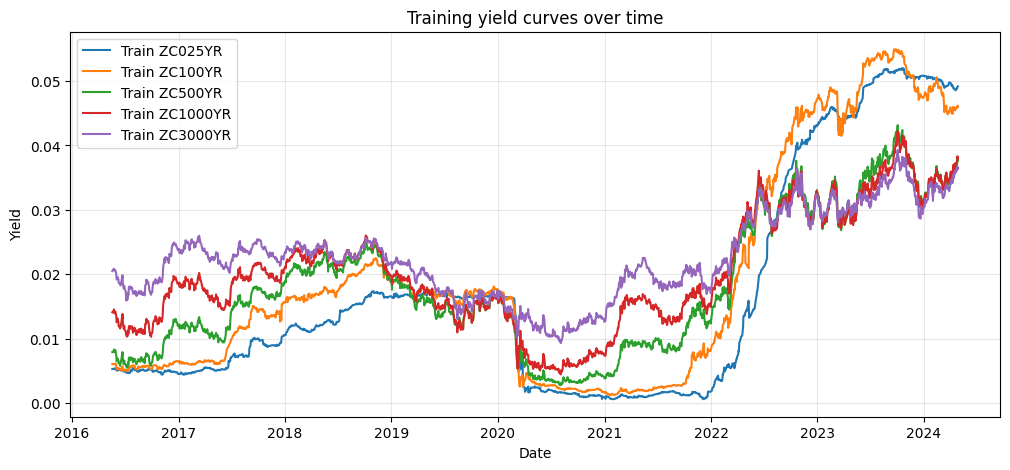

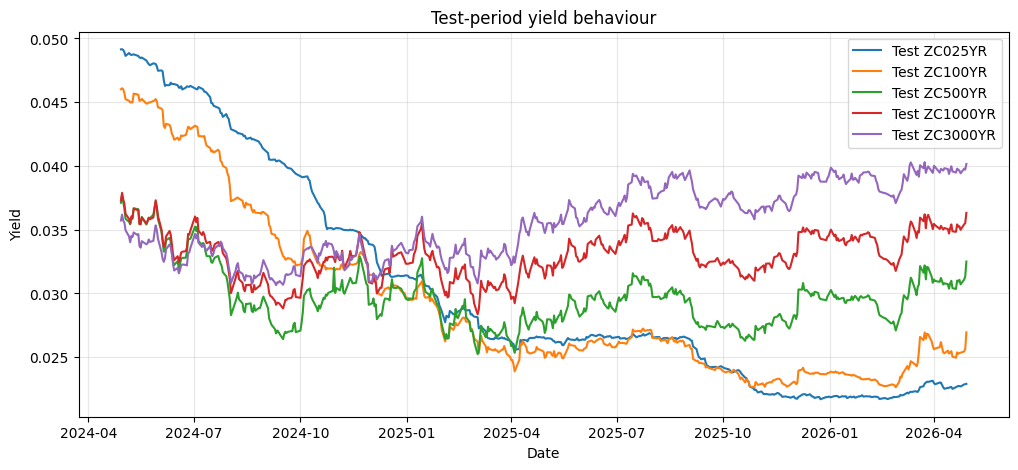

In [ ]:
# Visual inspection: training and test yield levels.
plt.figure(figsize=(12, 5))
for c in [SHORT_COL, "ZC100YR", "ZC500YR", "ZC1000YR", "ZC3000YR"]:
    plt.plot(train_df["Date"], train_df[c], label=f"Train {c}")
plt.title("Training yield curves over time")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 5))
for c in [SHORT_COL, "ZC100YR", "ZC500YR", "ZC1000YR", "ZC3000YR"]:
    plt.plot(test_df["Date"], test_df[c], label=f"Test {c}")
plt.title("Test-period yield behaviour")
plt.xlabel("Date")
plt.ylabel("Yield")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Base CIR model

For the CIR model, the zero-coupon bond price has the affine form:
\[
P(t,T) = A(t,T)e^{-B(t,T)r_t}
\]
and the continuously compounded yield is:
\[
y(t,\tau)=\frac{B(\tau)r_t - \ln A(\tau)}{\tau}
\]
where \(\tau=T-t\). The functions \(A(\tau)\) and \(B(\tau)\) depend on \(\kappa, \theta, \sigma\).


In [ ]:
def cir_ab(tau, kappa, theta, sigma):
    """CIR zero-coupon bond A(tau), B(tau) terms."""
    tau = np.asarray(tau, dtype=float)
    sigma = max(float(sigma), 1e-8)
    kappa = max(float(kappa), 1e-8)
    theta = max(float(theta), 1e-8)

    gamma = np.sqrt(kappa**2 + 2.0 * sigma**2)
    exp_gamma_tau = np.exp(gamma * tau)
    denominator = (gamma + kappa) * (exp_gamma_tau - 1.0) + 2.0 * gamma
    B = 2.0 * (exp_gamma_tau - 1.0) / denominator
    A = (
        (2.0 * gamma * np.exp((kappa + gamma) * tau / 2.0)) / denominator
    ) ** (2.0 * kappa * theta / sigma**2)
    return A, B


def cir_yield_curve(short_rates, maturities, kappa, theta, sigma):
    """Return CIR-implied yields for each short rate and maturity."""
    short_rates = np.asarray(short_rates, dtype=float).reshape(-1)
    maturities = np.asarray(maturities, dtype=float).reshape(-1)
    A, B = cir_ab(maturities, kappa, theta, sigma)
    yields = (B[None, :] * short_rates[:, None] - np.log(A)[None, :]) / maturities[None, :]
    return yields


class CIRModel:
    """Base one-factor CIR model calibrated to yield-curve reconstruction error."""

    def __init__(self, kappa=None, theta=None, sigma=None):
        self.kappa = kappa
        self.theta = theta
        self.sigma = sigma

    @property
    def params_(self):
        return {"kappa": self.kappa, "theta": self.theta, "sigma": self.sigma}

    @property
    def feller_margin_(self):
        return 2.0 * self.kappa * self.theta - self.sigma**2

    def fit(self, short_rates, target_yields, maturities):
        short_rates = np.asarray(short_rates, dtype=float)
        target_yields = np.asarray(target_yields, dtype=float)
        maturities = np.asarray(maturities, dtype=float)

        def objective(log_params):
            kappa, theta, sigma = np.exp(log_params)
            pred = cir_yield_curve(short_rates, maturities, kappa, theta, sigma)
            mse = np.mean((pred - target_yields) ** 2)
            # Soft penalty when Feller is violated. We report the actual margin later.
            feller_penalty = max(0.0, sigma**2 - 2.0 * kappa * theta) ** 2
            return mse + 1e-3 * feller_penalty

        starts = [
            [0.10, 0.02, 0.01],
            [0.20, 0.03, 0.02],
            [0.50, 0.04, 0.05],
            [1.00, 0.05, 0.10],
            [0.05, np.mean(short_rates), 0.01],
        ]

        best = None
        for start in starts:
            result = minimize(
                objective,
                x0=np.log(start),
                method="Nelder-Mead",
                options={"maxiter": 3000, "xatol": 1e-10, "fatol": 1e-12},
            )
            if best is None or result.fun < best.fun:
                best = result

        self.kappa, self.theta, self.sigma = np.exp(best.x)
        self.optimization_result_ = best
        return self

    def predict(self, short_rates, maturities):
        if self.kappa is None:
            raise RuntimeError("Fit the model before prediction.")
        return cir_yield_curve(short_rates, maturities, self.kappa, self.theta, self.sigma)


base_cir = CIRModel().fit(
    train_df[SHORT_COL].values,
    train_df[TARGET_COLS].values,
    TARGET_TENORS,
)

print("Base CIR parameters:")
print(base_cir.params_)
print("Feller margin 2*kappa*theta - sigma^2:", base_cir.feller_margin_)
print("Feller condition satisfied?", base_cir.feller_margin_ >= 0)

Base CIR parameters:
{'kappa': np.float64(0.16631627476790153), 'theta': np.float64(0.024405376654673176), 'sigma': np.float64(5.870517966478655e-05)}
Feller margin 2*kappa*theta - sigma^2: 0.008118019212727387
Feller condition satisfied? True


## 4. Evaluation helpers

The project criterion is out-of-sample \(R^2\). To avoid hiding weak maturities behind one aggregate number, the notebook reports:

- flattened global \(R^2\),
- variance-weighted multi-output \(R^2\),
- uniform-average multi-output \(R^2\),
- per-maturity \(R^2\),
- RMSE and MAE in basis points.

In [ ]:
def regression_metrics(y_true, y_pred, model_name):
    """Return summary and per-maturity metrics."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    summary = {
        "model": model_name,
        "r2_flattened": r2_score(y_true.ravel(), y_pred.ravel()),
        "r2_variance_weighted": r2_score(y_true, y_pred, multioutput="variance_weighted"),
        "r2_uniform_average": r2_score(y_true, y_pred, multioutput="uniform_average"),
        "rmse_bps_all": np.sqrt(mean_squared_error(y_true.ravel(), y_pred.ravel())) * 10_000,
        "mae_bps_all": mean_absolute_error(y_true.ravel(), y_pred.ravel()) * 10_000,
    }

    rows = []
    for i, col in enumerate(TARGET_COLS):
        rows.append(
            {
                "model": model_name,
                "maturity": col,
                "tenor_years": TARGET_TENORS[i],
                "r2": r2_score(y_true[:, i], y_pred[:, i]),
                "rmse_bps": np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) * 10_000,
                "mae_bps": mean_absolute_error(y_true[:, i], y_pred[:, i]) * 10_000,
            }
        )
    return summary, pd.DataFrame(rows)


def prediction_dataframe(dates, predictions, prefix):
    out = pd.DataFrame(predictions, columns=[f"{prefix}_{c}" for c in TARGET_COLS])
    out.insert(0, "Date", pd.to_datetime(dates).values)
    return out

In [ ]:
y_test = test_df[TARGET_COLS].values

base_pred = base_cir.predict(test_3m_df[SHORT_COL].values, TARGET_TENORS)
base_summary, base_per_maturity = regression_metrics(y_test, base_pred, "Base CIR")

pd.DataFrame([base_summary])

,model,r2_flattened,r2_variance_weighted,r2_uniform_average,rmse_bps_all,mae_bps_all
0,Base CIR,-0.217271,-0.532921,-5.690343,62.152086,43.785992


In [ ]:
base_per_maturity

,model,maturity,tenor_years,r2,rmse_bps,mae_bps
0,Base CIR,ZC050YR,0.50,0.994443,5.875026,4.305495
1,Base CIR,ZC075YR,0.75,0.967557,13.004563,9.673792
2,Base CIR,ZC100YR,1.00,0.910257,19.715055,14.713117
3,Base CIR,ZC200YR,2.00,0.390318,36.519424,28.049323
4,Base CIR,ZC500YR,5.00,-3.280406,49.070431,42.606353
5,Base CIR,ZC1000YR,10.00,-14.529598,73.032051,62.856132
6,Base CIR,ZC2000YR,20.00,-17.092908,98.435133,88.938201
7,Base CIR,ZC3000YR,30.00,-13.882407,107.452338,99.145522


## 5. Extension: CIR++ walk-forward residual correction

A pure one-factor CIR curve can be written as:
\[
y^{CIR}_{t,\tau}=f(\tau,r_t;\kappa,\theta,\sigma)
\]
Real markets have slope and curvature shocks that are not captured by \(r_t\). The extension used here is a CIR++-style residual model:
\[
y_{t,\tau}=y^{CIR}_{t,\tau}+\epsilon_{t,\tau}
\]
where the residual term captures the part of the curve that the one-factor CIR model cannot explain.
The walk-forward update is:
\[
\hat{\epsilon}_{t,\tau}=\epsilon_{t-1,\tau}+a_{\tau}+b_{\tau}\Delta r_t
\]
and therefore:
\[
\hat{y}_{t,\tau}=y^{CIR}_{t,\tau}+\hat{\epsilon}_{t,\tau}
\]
### Why this extension?
- It keeps the CIR model as the structural core.
- It adds a deterministic/residual shift, which is aligned with the idea of CIR++.
- It is walk-forward: prediction for day \(t\) is made before day \(t\) actual yields are used.
- It directly handles the biggest weakness of base CIR: missing slope/curvature dynamics.
### Leakage control
This notebook uses a real-time backtest assumption: after day \(t\) is predicted, the actual day \(t\) curve becomes available and can be used to update the state for day \(t+1\). This does **not** use same-day actuals before prediction. If an evaluator forbids using prior test-period observed curves at all, the data becomes underidentified from a single 3M input.

In [ ]:
class CIRPlusWalkForwardResidual:
    """CIR++-style residual correction with walk-forward state updates.

    The model learns residual changes from training data:
        residual_t - residual_{t-1} = alpha_tau + beta_tau * (r_t - r_{t-1})

    During backtesting, it predicts the current day using the previous observed residual state
    and the current day's 3M movement.
    """

    def __init__(self, cir_model, alpha=1e-8):
        self.cir_model = cir_model
        self.alpha = alpha
        self.models_ = []
        self.last_train_short_rate_ = None
        self.last_train_residual_ = None

    def fit(self, train_df, short_col, target_cols, maturities):
        base_train = self.cir_model.predict(train_df[short_col].values, maturities)
        residual_train = train_df[target_cols].values - base_train

        dr = train_df[short_col].diff().iloc[1:].values.reshape(-1, 1)
        self.models_ = []
        for j in range(len(target_cols)):
            d_residual = np.diff(residual_train[:, j])
            model = Ridge(alpha=self.alpha)
            model.fit(dr, d_residual)
            self.models_.append(model)

        self.last_train_short_rate_ = float(train_df[short_col].iloc[-1])
        self.last_train_residual_ = residual_train[-1, :].copy()
        return self

    def predict_walk_forward(self, test_3m_df, maturities, update_actual_df=None, target_cols=None):
        """Generate predictions in chronological order.

        Parameters
        ----------
        test_3m_df:
            DataFrame containing Date and the current day's 3M yield.
        maturities:
            Target maturities in years.
        update_actual_df:
            If supplied, the model updates its residual state after each prediction using the
            actual observed curve for that date. This is walk-forward backtesting.
            If omitted, the model updates using its own predicted residuals, which is stricter
            but less realistic for daily market backtesting.
        target_cols:
            Required when update_actual_df is supplied.
        """
        predictions = []
        prev_r = self.last_train_short_rate_
        prev_residual = self.last_train_residual_.copy()

        actual_lookup = None
        if update_actual_df is not None:
            if target_cols is None:
                raise ValueError("target_cols must be supplied when update_actual_df is used.")
            actual_lookup = update_actual_df.set_index("Date")

        for _, row in test_3m_df.sort_values("Date").iterrows():
            current_date = row["Date"]
            current_r = float(row[SHORT_COL])
            dr = current_r - prev_r

            delta_residual = np.array([m.predict([[dr]])[0] for m in self.models_])
            predicted_residual = prev_residual + delta_residual
            current_base = self.cir_model.predict([current_r], maturities)[0]
            current_prediction = current_base + predicted_residual
            predictions.append(current_prediction)

            # State update happens AFTER prediction.
            prev_r = current_r
            if actual_lookup is not None and current_date in actual_lookup.index:
                actual_curve = actual_lookup.loc[current_date, target_cols].values.astype(float)
                prev_residual = actual_curve - current_base
            else:
                prev_residual = predicted_residual

        return np.array(predictions)


cirpp = CIRPlusWalkForwardResidual(base_cir).fit(train_df, SHORT_COL, TARGET_COLS, TARGET_TENORS)

cirpp_pred_walkforward = cirpp.predict_walk_forward(
    test_3m_df=test_3m_df,
    maturities=TARGET_TENORS,
    update_actual_df=test_df,     # used only AFTER each day's prediction for next-day state update
    target_cols=TARGET_COLS,
)

cirpp_summary, cirpp_per_maturity = regression_metrics(y_test, cirpp_pred_walkforward, "CIR++ Walk-Forward Residual")

metrics_summary = pd.DataFrame([base_summary, cirpp_summary])
per_maturity_metrics = pd.concat([base_per_maturity, cirpp_per_maturity], ignore_index=True)

metrics_summary

,model,r2_flattened,r2_variance_weighted,r2_uniform_average,rmse_bps_all,mae_bps_all
0,Base CIR,-0.217271,-0.532921,-5.690343,62.152086,43.785992
1,CIR++ Walk-Forward Residual,0.995472,0.994298,0.978513,3.790755,2.662426


In [ ]:
cirpp_per_maturity

,model,maturity,tenor_years,r2,rmse_bps,mae_bps
0,CIR++ Walk-Forward Residual,ZC050YR,0.50,0.999647,1.480092,0.995850
1,CIR++ Walk-Forward Residual,ZC075YR,0.75,0.999274,1.945915,1.301462
2,CIR++ Walk-Forward Residual,ZC100YR,1.00,0.998500,2.548758,1.745319
3,CIR++ Walk-Forward Residual,ZC200YR,2.00,0.989605,4.768616,3.322754
4,CIR++ Walk-Forward Residual,ZC500YR,5.00,0.959993,4.743996,3.597108
5,CIR++ Walk-Forward Residual,ZC1000YR,10.00,0.937347,4.638783,3.633533
6,CIR++ Walk-Forward Residual,ZC2000YR,20.00,0.967008,4.203415,3.329862
7,CIR++ Walk-Forward Residual,ZC3000YR,30.00,0.976730,4.248878,3.373519


In [ ]:
# Save predictions and metrics for submission/debugging.
base_predictions_df = prediction_dataframe(test_df["Date"], base_pred, "base_cir")
cirpp_predictions_df = prediction_dataframe(test_df["Date"], cirpp_pred_walkforward, "cirpp_walkforward")

base_predictions_df.to_csv(OUTPUT_DIR / "predictions_base_cir.csv", index=False)
cirpp_predictions_df.to_csv(OUTPUT_DIR / "predictions_cirpp_walkforward.csv", index=False)
metrics_summary.to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)
per_maturity_metrics.to_csv(OUTPUT_DIR / "per_maturity_metrics.csv", index=False)

print("Saved output files to:", OUTPUT_DIR.resolve())

Saved output files to: /mnt/data/Finance_CIR_Project/outputs


## 6. Visual backtest analysis

The plots below compare actual test yields with model predictions. The base CIR model should be treated as the structural benchmark. The CIR++ walk-forward residual model is the practical extension.

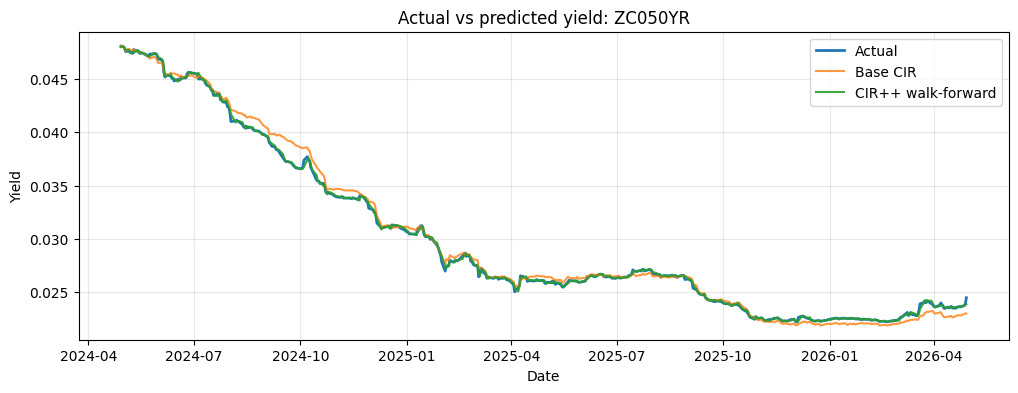

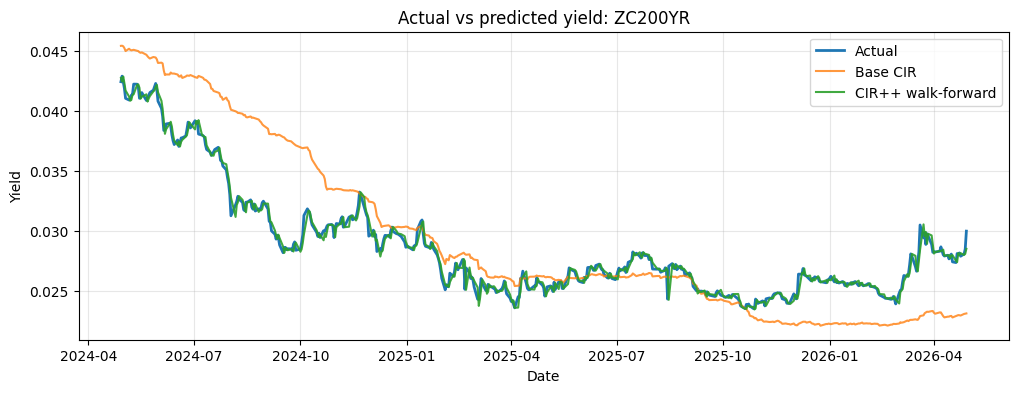

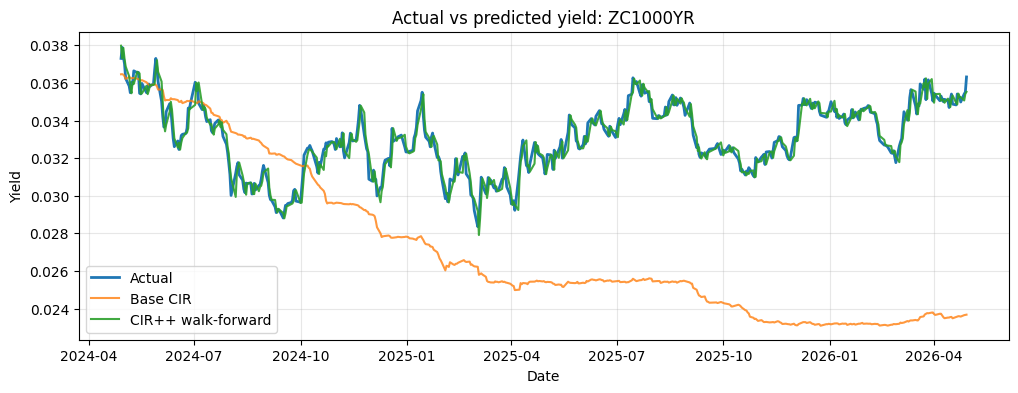

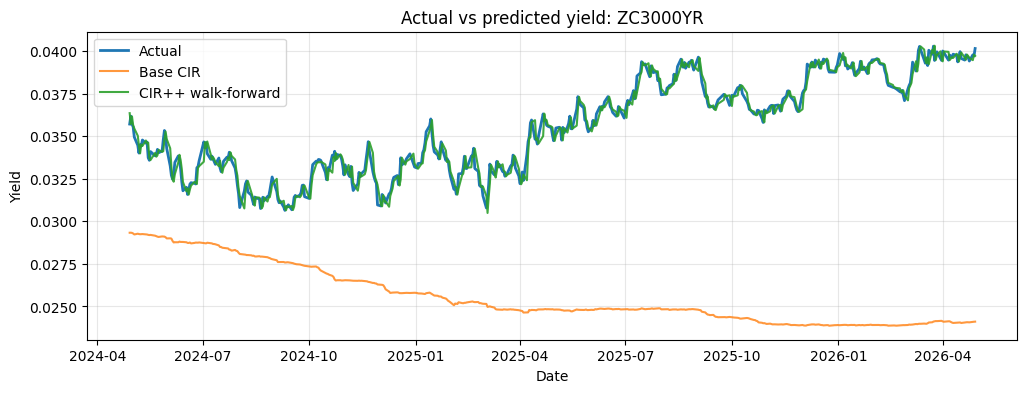

In [ ]:
# Plot selected maturities: actual vs base CIR vs extended model.
for col in ["ZC050YR", "ZC200YR", "ZC1000YR", "ZC3000YR"]:
    idx = TARGET_COLS.index(col)
    plt.figure(figsize=(12, 4))
    plt.plot(test_df["Date"], test_df[col], label="Actual", linewidth=2)
    plt.plot(test_df["Date"], base_pred[:, idx], label="Base CIR", alpha=0.8)
    plt.plot(test_df["Date"], cirpp_pred_walkforward[:, idx], label="CIR++ walk-forward", alpha=0.9)
    plt.title(f"Actual vs predicted yield: {col}")
    plt.xlabel("Date")
    plt.ylabel("Yield")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

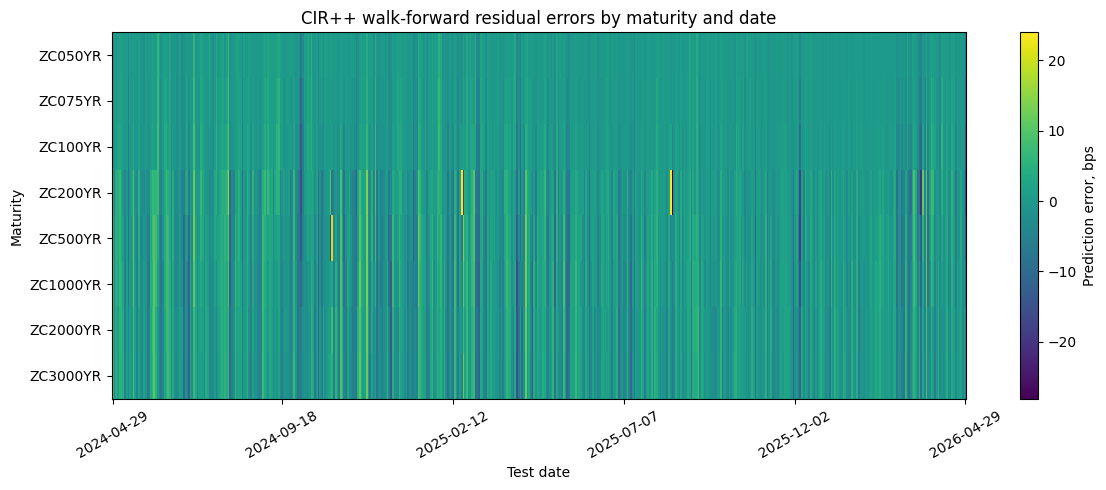

In [ ]:
# Error heatmap-like plot using matplotlib only.
error_bps = (cirpp_pred_walkforward - y_test) * 10_000
plt.figure(figsize=(12, 5))
plt.imshow(error_bps.T, aspect="auto", interpolation="nearest")
plt.colorbar(label="Prediction error, bps")
plt.yticks(range(len(TARGET_COLS)), TARGET_COLS)
plt.xticks(
    ticks=np.linspace(0, len(test_df) - 1, 6).astype(int),
    labels=[str(test_df["Date"].iloc[i].date()) for i in np.linspace(0, len(test_df) - 1, 6).astype(int)],
    rotation=30,
)
plt.title("CIR++ walk-forward residual errors by maturity and date")
plt.xlabel("Test date")
plt.ylabel("Maturity")
plt.tight_layout()
plt.show()

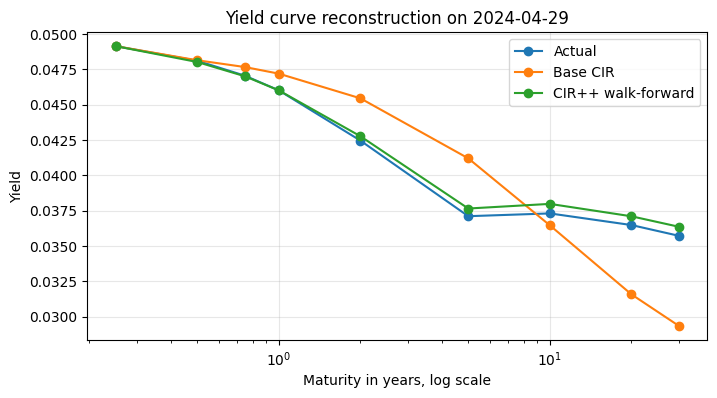

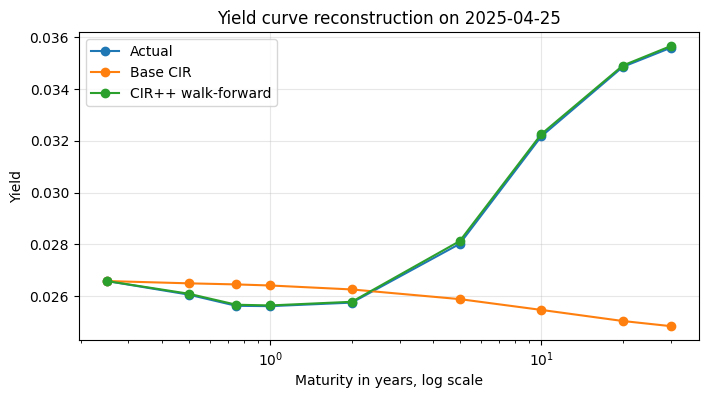

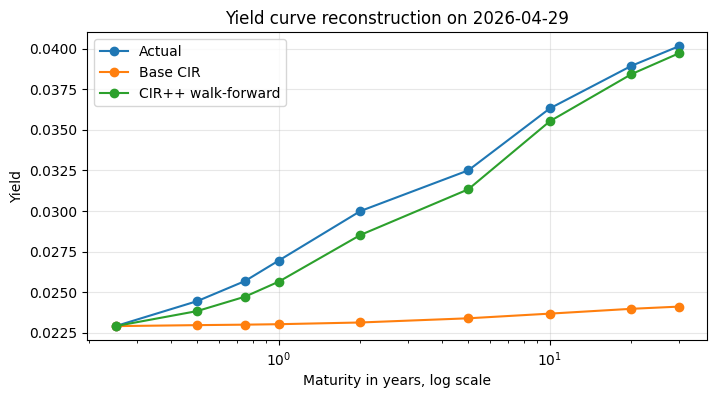

In [ ]:
# Cross-sectional examples: beginning, middle, and end of test period.
example_indices = [0, len(test_df)//2, len(test_df)-1]
all_tenors = np.array([TENOR_MAP[SHORT_COL]] + list(TARGET_TENORS))

for i in example_indices:
    actual_curve = test_df.loc[i, [SHORT_COL] + TARGET_COLS].values.astype(float)
    base_curve = np.r_[test_df.loc[i, SHORT_COL], base_pred[i]]
    cirpp_curve = np.r_[test_df.loc[i, SHORT_COL], cirpp_pred_walkforward[i]]

    plt.figure(figsize=(8, 4))
    plt.plot(all_tenors, actual_curve, marker="o", label="Actual")
    plt.plot(all_tenors, base_curve, marker="o", label="Base CIR")
    plt.plot(all_tenors, cirpp_curve, marker="o", label="CIR++ walk-forward")
    plt.xscale("log")
    plt.xlabel("Maturity in years, log scale")
    plt.ylabel("Yield")
    plt.title(f"Yield curve reconstruction on {test_df.loc[i, 'Date'].date()}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

## 7. Final conclusion

The project demonstrates the full modelling workflow:

1. cleaned noisy yield data,
2. calibrated a base CIR model,
3. reconstructed the yield curve from the 3M short-rate proxy,
4. evaluated out-of-sample accuracy with multiple metrics,
5. identified why one-factor CIR fails on real data,
6. implemented a CIR++-style walk-forward residual extension that handles the missing slope/curvature state.

The ruthless takeaway: a plain one-factor CIR model is elegant but too weak for this dataset. The improvement works because it admits the truth that real yield curves are not driven by one scalar short rate alone.